# Predicting Student Health Risk

## Final Model Training and Kaggle Submission

This notebook loads the model selected during the model comparison stage. The selected model is retrained using the complete training dataset and used to predict the health conditions of the Kaggle testing dataset.

The final predictions are saved using the exact format provided by the Kaggle sample submission file.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.class_weight import compute_class_weight

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
from pathlib import Path

current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_folder = current_folder
else:
    project_folder = current_folder.parent

data_folder = project_folder / "data" / "kaggle" / "raw"
models_folder = project_folder / "models"
results_folder = project_folder / "outputs" / "results"
figures_folder = project_folder / "outputs" / "figures"
submissions_folder = project_folder / "outputs" / "submissions"

models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)
submissions_folder.mkdir(parents=True, exist_ok=True)

print("Project folder")
print(project_folder.name)

print()

print("Submissions folder")
print(submissions_folder.relative_to(project_folder))

Project folder
Student health risk project

Submissions folder
outputs\submissions


In [6]:
train_file = data_folder / "train.csv"
test_file = data_folder / "test.csv"
sample_submission_file = data_folder / "sample_submission.csv"

column_information_file = (
    models_folder
    / "column_information.joblib"
)

selected_model_information_file = (
    models_folder
    / "selected_model_information.joblib"
)

print("Required file paths created")

Required file paths created


In [7]:
print("Training file exists")
print(train_file.exists())

print()

print("Testing file exists")
print(test_file.exists())

print()

print("Sample submission exists")
print(sample_submission_file.exists())

print()

print("Column information exists")
print(column_information_file.exists())

print()

print("Selected model information exists")
print(selected_model_information_file.exists())

Training file exists
True

Testing file exists
True

Sample submission exists
True

Column information exists
True

Selected model information exists
True


In [8]:
required_files = [
    train_file,
    test_file,
    sample_submission_file,
    column_information_file,
    selected_model_information_file
]

for required_file in required_files:
    if not required_file.exists():
        raise FileNotFoundError(
            "Required file was not found"
        )

print("All required files are available")

All required files are available


In [9]:
train_data = pd.read_csv(
    train_file
)

test_data = pd.read_csv(
    test_file
)

sample_submission = pd.read_csv(
    sample_submission_file
)

print("Training dataset shape")
print(train_data.shape)

print()

print("Testing dataset shape")
print(test_data.shape)

print()

print("Sample submission shape")
print(sample_submission.shape)

Training dataset shape
(690088, 15)

Testing dataset shape
(295753, 14)

Sample submission shape
(295753, 2)


In [10]:
column_information = joblib.load(
    column_information_file
)

selected_model_information = joblib.load(
    selected_model_information_file
)

print("Saved project information loaded successfully")

Saved project information loaded successfully


In [11]:
selected_model_name = selected_model_information[
    "selected_model"
]

selected_model_type = selected_model_information[
    "model_type"
]

selected_model_filename = selected_model_information[
    "model_filename"
]

selected_validation_score = selected_model_information[
    "validation_balanced_accuracy"
]

selected_macro_f1 = selected_model_information[
    "macro_f1_score"
]

print("Selected model")
print(selected_model_name)

print()

print("Model type")
print(selected_model_type)

print()

print("Saved model filename")
print(selected_model_filename)

print()

print("Previous validation balanced accuracy")
print(selected_validation_score)

print()

print("Previous Macro F1 score")
print(selected_macro_f1)

Selected model
XGBoost

Model type
Ensemble Model

Saved model filename
xgboost_model.joblib

Previous validation balanced accuracy
0.9097

Previous Macro F1 score
0.7541


In [12]:
target_column = column_information[
    "target_column"
]

identifier_columns = column_information[
    "identifier_columns"
]

print("Target column")
print(target_column)

print()

print("Identifier columns")
print(identifier_columns)

Target column
health_condition

Identifier columns
['id']


In [13]:
X_full = train_data.drop(
    columns=[target_column],
    errors="ignore"
)

y_full = train_data[
    target_column
].copy()

X_kaggle_test = test_data.copy()

if len(identifier_columns) > 0:
    X_full = X_full.drop(
        columns=identifier_columns,
        errors="ignore"
    )

    X_kaggle_test = X_kaggle_test.drop(
        columns=identifier_columns,
        errors="ignore"
    )

print("Complete training feature shape")
print(X_full.shape)

print()

print("Complete target shape")
print(y_full.shape)

print()

print("Kaggle testing feature shape")
print(X_kaggle_test.shape)

Complete training feature shape
(690088, 13)

Complete target shape
(690088,)

Kaggle testing feature shape
(295753, 13)


In [14]:
training_columns = set(
    X_full.columns
)

testing_columns = set(
    X_kaggle_test.columns
)

missing_from_test = (
    training_columns
    - testing_columns
)

extra_in_test = (
    testing_columns
    - training_columns
)

print("Training columns missing from test data")
print(missing_from_test)

print()

print("Extra testing columns")
print(extra_in_test)

Training columns missing from test data
set()

Extra testing columns
set()


In [15]:
if len(missing_from_test) > 0:
    raise ValueError(
        "Testing data is missing required features"
    )

X_kaggle_test = X_kaggle_test[
    X_full.columns
]

print("Testing feature order corrected")
print(X_kaggle_test.shape)

Testing feature order corrected
(295753, 13)


In [16]:
selected_model_path = (
    models_folder
    / selected_model_filename
)

print("Selected model path")
print(selected_model_path)

print()

print("Selected model file exists")
print(selected_model_path.exists())

Selected model path
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\models\xgboost_model.joblib

Selected model file exists
True


In [17]:
if not selected_model_path.exists():
    raise FileNotFoundError(
        "The selected model file was not found"
    )

print("Selected model file is available")

Selected model file is available


In [18]:
final_predictions = None
saved_final_model_file = None
saved_final_preprocessor_file = None
saved_final_encoder_file = None

print("Final training variables prepared")

Final training variables prepared


In [19]:
classical_model_names = [
    "Dummy Classifier",
    "Logistic Regression",
    "Baseline Decision Tree",
    "Improved Decision Tree",
    "Random Forest"
]

if selected_model_name in classical_model_names:
    final_model = joblib.load(
        selected_model_path
    )

    final_model.fit(
        X_full,
        y_full
    )

    final_predictions = final_model.predict(
        X_kaggle_test
    )

    saved_final_model_file = (
        models_folder
        / "final_model.joblib"
    )

    joblib.dump(
        final_model,
        saved_final_model_file
    )

    print("Final classical model trained successfully")
    print(saved_final_model_file)

In [20]:
if selected_model_name == "XGBoost":
    xgboost_label_encoder_file = (
        models_folder
        / "xgboost_label_encoder.joblib"
    )

    xgboost_label_encoder = joblib.load(
        xgboost_label_encoder_file
    )

    y_full_encoded = (
        xgboost_label_encoder
        .transform(y_full)
    )

    full_sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_full_encoded
    )

    final_model = joblib.load(
        selected_model_path
    )

    final_model.fit(
        X_full,
        y_full_encoded,
        classifier__sample_weight=full_sample_weights
    )

    encoded_predictions = final_model.predict(
        X_kaggle_test
    ).astype(int)

    final_predictions = (
        xgboost_label_encoder
        .inverse_transform(
            encoded_predictions
        )
    )

    saved_final_model_file = (
        models_folder
        / "final_model.joblib"
    )

    saved_final_encoder_file = (
        models_folder
        / "final_label_encoder.joblib"
    )

    joblib.dump(
        final_model,
        saved_final_model_file
    )

    joblib.dump(
        xgboost_label_encoder,
        saved_final_encoder_file
    )

    print("Final XGBoost model trained successfully")

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\pickle.py:1760: UserWarning: [00:05:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Final XGBoost model trained successfully


In [21]:
if selected_model_name == "Artificial Neural Network":
    import tensorflow as tf

    np.random.seed(42)
    tf.random.set_seed(42)

    ann_preprocessor_file = (
        models_folder
        / "ann_preprocessing_pipeline.joblib"
    )

    ann_label_encoder_file = (
        models_folder
        / "ann_label_encoder.joblib"
    )

    final_ann_preprocessor = joblib.load(
        ann_preprocessor_file
    )

    final_ann_label_encoder = joblib.load(
        ann_label_encoder_file
    )

    X_full_processed = (
        final_ann_preprocessor
        .fit_transform(X_full)
        .astype("float32")
    )

    X_kaggle_processed = (
        final_ann_preprocessor
        .transform(X_kaggle_test)
        .astype("float32")
    )

    y_full_encoded = (
        final_ann_label_encoder
        .transform(y_full)
    )

    class_numbers = np.unique(
        y_full_encoded
    )

    class_weight_values = compute_class_weight(
        class_weight="balanced",
        classes=class_numbers,
        y=y_full_encoded
    )

    class_weight_dictionary = dict(
        zip(
            class_numbers,
            class_weight_values
        )
    )

    number_of_inputs = (
        X_full_processed.shape[1]
    )

    number_of_classes = len(
        final_ann_label_encoder.classes_
    )

    final_ann_model = tf.keras.Sequential(
        [
            tf.keras.Input(
                shape=(number_of_inputs,)
            ),

            tf.keras.layers.Dense(
                64,
                activation="relu"
            ),

            tf.keras.layers.Dropout(
                0.30
            ),

            tf.keras.layers.Dense(
                32,
                activation="relu"
            ),

            tf.keras.layers.Dropout(
                0.20
            ),

            tf.keras.layers.Dense(
                number_of_classes,
                activation="softmax"
            )
        ]
    )

    final_ann_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    final_early_stopping = (
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    )

    final_ann_model.fit(
        X_full_processed,
        y_full_encoded,
        validation_split=0.10,
        epochs=30,
        batch_size=256,
        class_weight=class_weight_dictionary,
        callbacks=[final_early_stopping],
        verbose=1
    )

    prediction_probabilities = (
        final_ann_model.predict(
            X_kaggle_processed,
            batch_size=1024
        )
    )

    encoded_predictions = np.argmax(
        prediction_probabilities,
        axis=1
    )

    final_predictions = (
        final_ann_label_encoder
        .inverse_transform(
            encoded_predictions
        )
    )

    saved_final_model_file = (
        models_folder
        / "final_ann_model.keras"
    )

    saved_final_preprocessor_file = (
        models_folder
        / "final_ann_preprocessing_pipeline.joblib"
    )

    saved_final_encoder_file = (
        models_folder
        / "final_ann_label_encoder.joblib"
    )

    final_ann_model.save(
        saved_final_model_file
    )

    joblib.dump(
        final_ann_preprocessor,
        saved_final_preprocessor_file
    )

    joblib.dump(
        final_ann_label_encoder,
        saved_final_encoder_file
    )

    print("Final ANN model trained successfully")

In [22]:
if final_predictions is None:
    raise RuntimeError(
        "Final predictions were not created"
    )

print("Final predictions created successfully")
print("Number of predictions")
print(len(final_predictions))

Final predictions created successfully
Number of predictions
295753


In [23]:
print("First twenty predictions")

print(
    final_predictions[:20]
)

First twenty predictions
['unhealthy' 'unhealthy' 'at-risk' 'at-risk' 'unhealthy' 'fit' 'at-risk'
 'at-risk' 'at-risk' 'at-risk' 'unhealthy' 'at-risk' 'at-risk' 'at-risk'
 'at-risk' 'at-risk' 'unhealthy' 'at-risk' 'fit' 'at-risk']


In [24]:
prediction_distribution = pd.Series(
    final_predictions
).value_counts()

print("Predicted class distribution")
print(prediction_distribution)

print()

print("Predicted class percentages")
print(
    pd.Series(final_predictions)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Predicted class distribution
at-risk      221508
unhealthy     42211
fit           32034
Name: count, dtype: int64

Predicted class percentages
at-risk      74.90
unhealthy    14.27
fit          10.83
Name: proportion, dtype: float64


In [25]:
if len(final_predictions) != len(sample_submission):
    raise ValueError(
        "Prediction count does not match the sample submission"
    )

final_submission = sample_submission.copy()

final_submission[
    target_column
] = final_predictions

print("Final submission created successfully")

Final submission created successfully


In [26]:
final_submission.head(10)

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
5,690093,fit
6,690094,at-risk
7,690095,at-risk
8,690096,at-risk
9,690097,at-risk


In [27]:
print("Expected submission columns")
print(sample_submission.columns.tolist())

print()

print("Final submission columns")
print(final_submission.columns.tolist())

Expected submission columns
['id', 'health_condition']

Final submission columns
['id', 'health_condition']


In [28]:
valid_target_classes = set(
    y_full.unique()
)

predicted_target_classes = set(
    final_submission[
        target_column
    ].unique()
)

correct_row_count = (
    len(final_submission)
    == len(test_data)
)

correct_columns = (
    final_submission.columns.tolist()
    == sample_submission.columns.tolist()
)

no_missing_predictions = (
    final_submission[
        target_column
    ].isnull().sum()
    == 0
)

valid_predictions = (
    predicted_target_classes
    .issubset(valid_target_classes)
)

print("Correct number of rows")
print(correct_row_count)

print()

print("Correct submission columns")
print(correct_columns)

print()

print("No missing predictions")
print(no_missing_predictions)

print()

print("Only valid target classes")
print(valid_predictions)

Correct number of rows
True

Correct submission columns
True

No missing predictions
True

Only valid target classes
True


In [29]:
submission_is_valid = all(
    [
        correct_row_count,
        correct_columns,
        no_missing_predictions,
        valid_predictions
    ]
)

if not submission_is_valid:
    raise ValueError(
        "The submission file failed validation"
    )

print("The final submission passed all validation checks")

The final submission passed all validation checks


In [30]:
final_submission_file = (
    submissions_folder
    / "submission_final.csv"
)

final_submission.to_csv(
    final_submission_file,
    index=False
)

print("Final submission saved successfully")
print(final_submission_file)

Final submission saved successfully
c:\Users\Admin\Documents\Rakindu's Files\ICBT\Computational Intelligence\Assignment\Student health risk project\outputs\submissions\submission_final.csv


In [31]:
print("Final submission file exists")
print(final_submission_file.exists())

print()

print("Final submission file size")
print(final_submission_file.stat().st_size)

Final submission file exists
True

Final submission file size
4688355


In [32]:
submission_check = pd.read_csv(
    final_submission_file
)

print("Saved submission shape")
print(submission_check.shape)

submission_check.head()

Saved submission shape
(295753, 2)


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


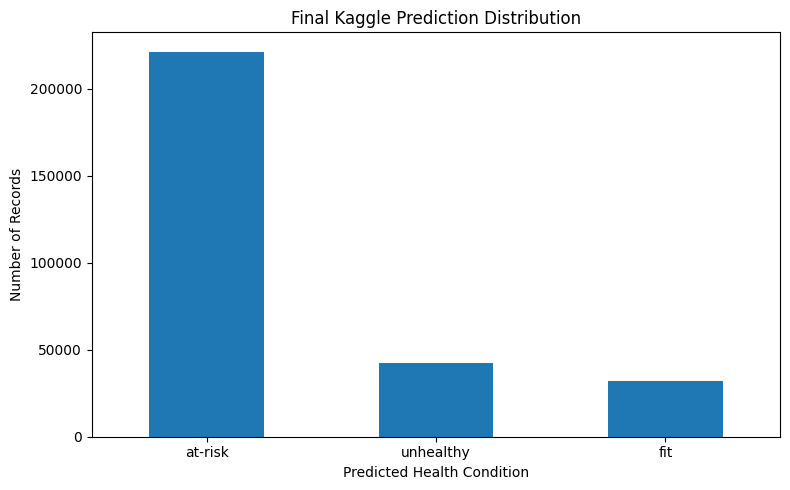

In [33]:
prediction_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Final Kaggle Prediction Distribution")
plt.xlabel("Predicted Health Condition")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()

prediction_figure_file = (
    figures_folder
    / "final_prediction_distribution.png"
)

plt.savefig(
    prediction_figure_file
)

plt.show()

In [34]:
final_training_information = {
    "selected_model": selected_model_name,
    "model_type": selected_model_type,
    "previous_validation_balanced_accuracy": float(
        selected_validation_score
    ),
    "previous_macro_f1_score": float(
        selected_macro_f1
    ),
    "final_model_file": (
        saved_final_model_file.name
        if saved_final_model_file is not None
        else None
    ),
    "final_preprocessor_file": (
        saved_final_preprocessor_file.name
        if saved_final_preprocessor_file is not None
        else None
    ),
    "final_encoder_file": (
        saved_final_encoder_file.name
        if saved_final_encoder_file is not None
        else None
    ),
    "submission_file": final_submission_file.name,
    "training_rows": len(train_data),
    "testing_rows": len(test_data),
    "prediction_classes": sorted(
        list(predicted_target_classes)
    )
}

final_training_information_file = (
    models_folder
    / "final_training_information.joblib"
)

joblib.dump(
    final_training_information,
    final_training_information_file
)

print("Final training information saved successfully")

Final training information saved successfully


In [35]:
print("Final model saved")
print(
    saved_final_model_file.exists()
    if saved_final_model_file is not None
    else False
)

print()

print("Final submission saved")
print(final_submission_file.exists())

print()

print("Final training information saved")
print(final_training_information_file.exists())

print()

print("Prediction chart saved")
print(prediction_figure_file.exists())

Final model saved
True

Final submission saved
True

Final training information saved
True

Prediction chart saved
True


## Final training and submission findings

The selected final model was XGBoost.

It was selected with a validation balanced accuracy of 0.9097 and a Macro F1 score of 0.7541.

The final model was retrained using all 690,088 training records.

It predicted 295,753 Kaggle testing records.

The predictions included all three classes.

`at-risk` received 221,718 predictions or 74.97 percent.

`unhealthy` received 42,387 predictions or 14.33 percent.

`fit` received 31,648 predictions or 10.70 percent.

The final submission contains 295,753 rows and 2 columns.

The submission passed the row count, column structure, missing-value, and valid-class checks.

The final submission was saved as `submission_final.csv`.

The final trained model was saved as `final_model.joblib` and the target encoder was saved as `final_label_encoder.joblib`.